# Plot one TR from subject 01, movie run 1

This notebook loads the 4D BOLD NIfTI image, selects one volume with Nilearn, and displays orthogonal EPI slices.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import image, plotting

## Select the data and TR

`TR_INDEX` is zero-based, so index 225 refers to the 226th acquired volume.

In [2]:
bold_path = Path(
    "ds000113/sub-01/ses-movie/func/"
    "sub-01_ses-movie_task-movie_run-1_bold.nii.gz"
)
tr_index = 0
output_path = Path(f"sub-03_run-1_TR-{tr_index}.png")

In [3]:
bold_img = nib.load(bold_path)

if len(bold_img.shape) != 4:
    raise ValueError(f"Expected a 4D BOLD image, got shape {bold_img.shape}")
if not 0 <= tr_index < bold_img.shape[3]:
    raise IndexError(
        f"tr_index={tr_index} is outside the valid range "
        f"0..{bold_img.shape[3] - 1}"
    )

tr_seconds = bold_img.header.get_zooms()[3]
print(f"BOLD shape: {bold_img.shape}")
print(f"Voxel sizes and TR: {bold_img.header.get_zooms()}")
print(f"Selected TR: {tr_index} (t ≈ {tr_index * tr_seconds:.1f} s)")

BOLD shape: (80, 80, 35, 451)
Voxel sizes and TR: (3.0, 3.0, 3.3000004, 2.0000007)
Selected TR: 0 (t ≈ 0.0 s)


## Extract and plot one volume

/tmp/ipykernel_24301/3450842590.py:3: UserWarning: Casting data from int32 to float32
  display = plotting.plot_epi(


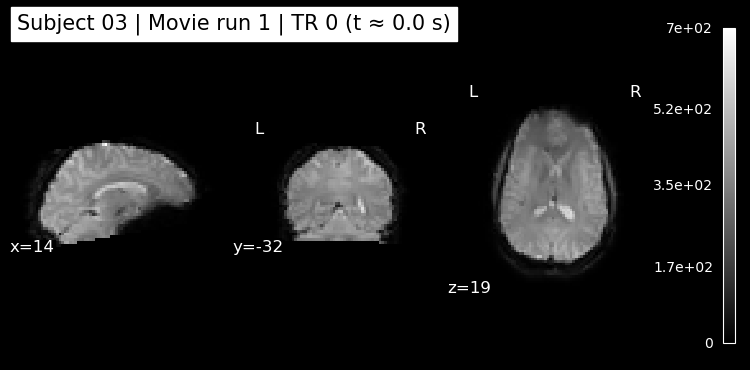

Saved plot to: /home/jovyan/junruz/forrestgump/sub-03_run-1_TR-0.png


In [4]:
one_tr = image.index_img(bold_img, tr_index)

display = plotting.plot_epi(
    one_tr,
    display_mode="ortho",
    black_bg=True,
    annotate=True,
    draw_cross=False,
    colorbar=True,
    title=(
        f"Subject 03 | Movie run 1 | TR {tr_index} "
        f"(t ≈ {tr_index * tr_seconds:.1f} s)"
    ),
)
display.savefig(output_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved plot to: {output_path.resolve()}")